## Pendekatan Tertutup

Metode pendekatan tertutup dilakukan dengan membatasi nilai estimasi akar ($x_r$) yang berada dalam rentang tertentu, batas bawah ($x_i$) dan  batas atas ($x_f$). Pada artikel ini akan membahas dua metode numerik untuk menghitung nilai akar yaitu, Metode Bagi Dua (Biseksi) dan Metode Regula Falsi.

### Metode Bagi Dua (Biseksi)

Perhitungan nilai akar ($x_r$) persamaan menggunakan metode biseksi dilakukan dengan membagi dua dengan persamaan

$x_r = \frac {x_i + x_f} {2}$

dari rentang batas yang didefinisikan $[x_i, x_f]$, dimana $x_i$ adalah batas awal dan $x_r$ adalah batas akhir. Jika $f(x_i) . f(x_f) < 0$, maka diasumsikan nilai akar, $x_r$, berada pada rentang $[x_i, x_f]$. Jika $x_r$ tidak berada dalam rentang yang didefinisikan, maka harus dipilih nilai batas yang baru.

**Algoritma Metode Biseksi**

1. Definisikan nilai batas awal ($x_i$) dan batas akhir ($x_f$) estimasi akar
2. Definisikan nilai toleransi, $tol = 0.001$
3. Definisikan nilai error awal, $error = 1$
4. Jika $f(xi) . f(xf) < 0$
   
   5.1 Selama $error > tol$ maka lakukan proses berikut
   
   - Hitung nilai akar, $x_r = \frac {x_i + x_f} {2}$
    
   - Jika $f(x_r) = 0$
      
      - akarnya adalah $x_r$.
      - $error = 0$
      - proses dihentikan

   - Jika $f(x_i) . f(x_r) < 0$
     - maka, $x_{old} = x_f$, dan $x_f = x_r$
   - Jika $f(x_i) . f(x_r) > 0$
     - maka, $x_{old} = x_i$, dan $x_i = x_r$
  
   5.2 Hitung nilai galat (error), $error = |\frac {x_r - x_{old}}{x_r}|$
  
   5.3 Jika $error$ > $tol$, proses 5.1 - 5.3 diulang

**Contoh Kasus**

Estimasi nilai $x$ yang memenuhi persamaan kuadrat $x^2 + 2x - 3 = 0$!

Jika persamaan tersebut diselesaikan dengan pendekatan analitik, persamaan kuadrat tersebut memiliki dua akar yang berbeda tanda, yaitu $x_1 = -3$ dan $x_2 = 1$.

Maka dari itu, kita bisa uji dengan menggunakan metode biseksi (bisection method) dimana batas nilai akar dapat didefinisikan dalam rentang batas awal $x_i = -5$ dan batas akhir $x_f = 0$. Asumsi batas toleransi sebesar $1e^{-3}$.


In [7]:
# Ini fungsi untuk hitung error
def cal_absolute_error(xr,xold):
  return abs((xr-xold)/xr)

In [8]:
# Ini fungsi untuk plot grafik

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

def plot_graphic(xmin, xmax, f, xroot, iterations, errors, title=None, xlabel='x'):
  x = np.linspace(xmin, xmax, 20)

  fig, ax = plt.subplots(figsize=(10,4), ncols=2)

  if title != None:
    plt.suptitle(f"{title}", fontsize=16)

  ax[0].plot(x, f(x), color='k', linewidth=2, label='f(x)')
  ax[0].plot(xroot, f(xroot), '.', color='red', markersize=10, label='root')
  ax[0].set_xlabel(xlabel)
  ax[0].set_ylabel('f(x)')
  # ax[0].xaxis.set_minor_locator(MultipleLocator(0.2))
  # ax[0].yaxis.set_minor_locator(MultipleLocator(1))
  ax[0].grid(which='both')
  ax[0].legend(loc='best')


  ax[1].plot(iterations, errors, color='k', linewidth=2)
  ax[1].set_xlabel('Iteration')
  ax[1].set_ylabel('Absolute Error')
  ax[1].xaxis.set_minor_locator(MultipleLocator(0.5))
  ax[1].yaxis.set_minor_locator(MultipleLocator(0.1))
  ax[1].grid(which='both')

  plt.tight_layout()


Nilai akar berada dalam rentang

Error: 1.00000, xr: -2.50000, f(xr): -1.75000
Error: 1.00000, xr: -3.75000, f(xr): 3.56250
Error: 0.33333, xr: -3.12500, f(xr): 0.51562
Error: 0.20000, xr: -2.81250, f(xr): -0.71484
Error: 0.11111, xr: -2.96875, f(xr): -0.12402
Error: 0.05263, xr: -3.04688, f(xr): 0.18970
Error: 0.02564, xr: -3.00781, f(xr): 0.03131
Error: 0.01299, xr: -2.98828, f(xr): -0.04674
Error: 0.00654, xr: -2.99805, f(xr): -0.00781
Error: 0.00326, xr: -3.00293, f(xr): 0.01173
Error: 0.00163, xr: -3.00049, f(xr): 0.00195

Jumlah perulangan (iterasi): 11
Nilai akar, xr: -3.000
f(xr) = 0.002, error = 0.0008


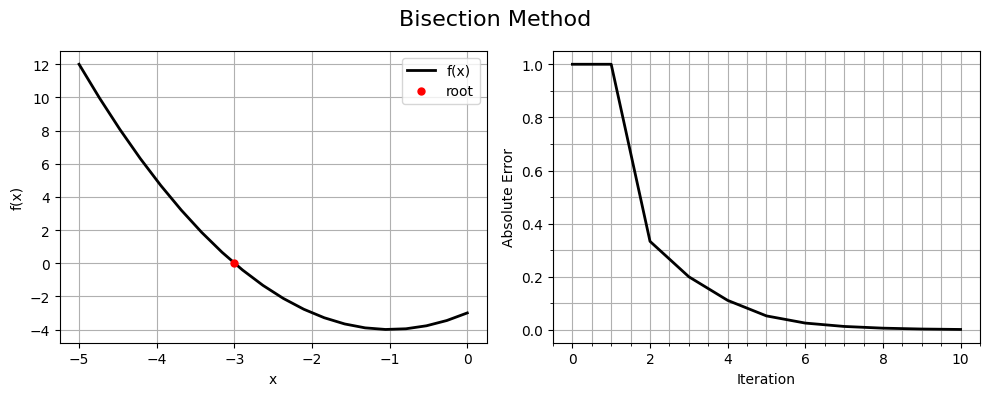

In [9]:
# Metode Biseksi (Bagi Dua)
# input batas akar
xi = -5 # batas awal
xf = 0 # batas akhir

# nilai toleransi error
tol = 1e-3
error = 1

# Jumlah iterasi
iter = 0

# definisikan fungsi kuadrat
f = lambda x : x**2 + (2*x) - 3

iteration, errors = [], []
if (f(xi) * f(xf)) < 0:
  print()
  print("Nilai akar berada dalam rentang")
  print()

  while error > tol:
    iteration.append(iter)
    errors.append(error)
    # hitung estimasi nilai akar awal
    xr = (xi + xf) / 2

    if f(xr) == 0:
      x_old = xr
      error = 0
      print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
      iter += 1
      break
    elif f(xi) * f(xr) < 0:
      x_old, xf = xf, xr
    elif f(xi) * f(xr) > 0:
      x_old, xi = xi, xr

    print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
    error = cal_absolute_error(xr,x_old)
    iter += 1

  print()
  print(f"Jumlah perulangan (iterasi): {iter}")
  print(f"Nilai akar, xr: {xr:.3f}")
  print(f"f(xr) = {f(xr):.3f}, error = {error:.4f}")
else:
  print("Masukan batas nilai yang baru")

# Plot grafik
plot_graphic(-5,0,f,xr,iteration, errors, title='Bisection Method')

### Metode Regula Falsi

Mendapatkan nilai akar menggunakan metode regula falsi dengan mencari titik perpotongan yang menghubungkan dua titik antara $(x_i, f(x_i))$ dan $(x_f, f(x_f))$, dimana suatu nilai akar ($x_r$) memotong di sumbu-x. Persamaan garis yang melalui dua titik ditulis sebagai berikut

$\frac {y - f(x_i)}{f(x_f) - f(x_i)} = \frac {x - x_i}{x_f - x_i}$

persamaan garis akan memotong dimana $x=x_r$ dan $y=0$, maka persamaan di atas dapat ditulis menjadi

$x_r = x_i - \frac {f(x_i) (x_f - x_i)}{f(x_f) - f(x_i)}$

Sama seperti metode biseksi, syarat untuk memenuhi akar dalam suatu rentang adalah $f(x_i) . f(x_f) < 0$. Algoritma metode regula falsi dapat ditulis sebagai berikut

1. Definisikan nilai batas awal ($x_i$) dan batas akhir ($x_f$) estimasi akar
2. Definisikan nilai toleransi, $tol = 0.001$
3. Definisikan nilai error awal, $error = 1$
4. Jika $f(xi) . f(xf) < 0$
   
   5.1 Selama $error > tol$ maka lakukan proses berikut
   
   - Hitung nilai akar, $x_r = x_i - \frac {f(x_i) (x_f - x_i)}{f(x_f) - f(x_i)}$
    
   - Jika $f(x_r) = 0$
      
      - akarnya adalah $x_r$.
      - $error = 0$
      - proses dihentikan

   - Jika $f(x_i) . f(x_r) < 0$
     - maka, $x_{old} = x_f$, dan $x_f = x_r$
   - Jika $f(x_i) . f(x_r) > 0$
     - maka, $x_{old} = x_i$, dan $x_i = x_r$
  
   5.2 Hitung nilai galat (error), $error = |\frac {x_r - x_{old}}{x_r}|$
  
   5.3 Jika $error$ > $tol$, proses 5.1 - 5.3 diulang


   **Contoh Kasus**

   Menggunakan persamaan kuadrat yang sama seperti pada metode biseksi, $x^2 + 2x - 3 = 0$, estimasikan nilai akarnya dengan batas awal $x_i = -5$ dan batas akhir $x_f = 0$.


Nilai akar berada dalam rentang

Error: 1.00000, xr: -1.00000, f(xr): -4.00000
Error: 1.00000, xr: -2.00000, f(xr): -3.00000
Error: 0.50000, xr: -2.60000, f(xr): -1.44000
Error: 0.23077, xr: -2.85714, f(xr): -0.55102
Error: 0.09000, xr: -2.95122, f(xr): -0.19274
Error: 0.03188, xr: -2.98361, f(xr): -0.06531
Error: 0.01085, xr: -2.99452, f(xr): -0.02189
Error: 0.00364, xr: -2.99817, f(xr): -0.00731
Error: 0.00122, xr: -2.99939, f(xr): -0.00244

Jumlah perulangan (iterasi): 9
Nilai akar, xr: -2.999
f(xr) = -0.002, error = 0.0004


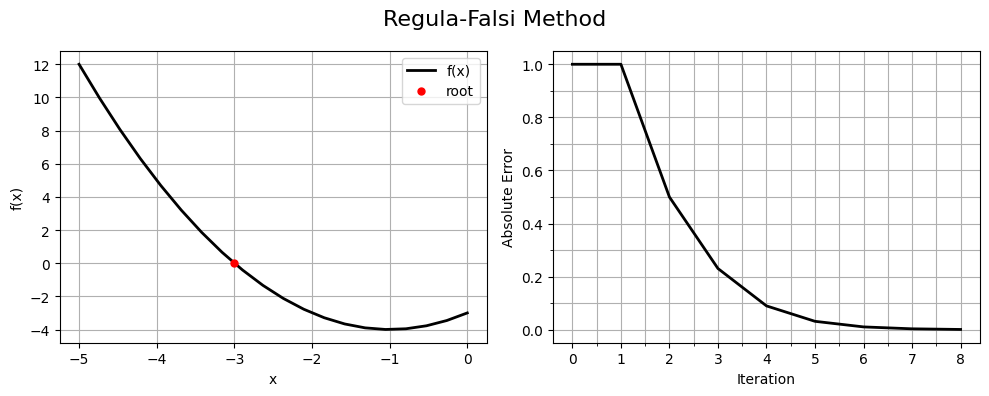

In [10]:
# input batas akar
xi = -5 # batas awal
xf = 0 # batas akhir

# nilai toleransi error
tol = 1e-3
error = 1

# jumlah iterasi awal
iter = 0

# definisikan fungsi kuadrat
f = lambda x : x**2 + (2*x) - 3

if (f(xi) * f(xf)) < 0:
  print()
  print("Nilai akar berada dalam rentang")
  print()

  iteration, errors = [], []
  while error > tol:
    iteration.append(iter)
    errors.append(error)
    # hitung estimasi nilai akar awal
    xr = xi - ((f(xi)*(xf - xi))/(f(xf) - f(xi)))

    if f(xr) == 0:
      x_old = xr
      error = 0
      print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
      iter += 1
      break
    elif f(xi) * f(xr) < 0:
      x_old, xf = xf, xr
    elif f(xi) * f(xr) > 0:
      x_old, xi = xi, xr

    print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
    error = cal_absolute_error(xr,x_old)

    iter += 1
  print()
  print(f"Jumlah perulangan (iterasi): {iter}")
  print(f"Nilai akar, xr: {xr:.3f}")
  print(f"f(xr) = {f(xr):.3f}, error = {error:.4f}")
else:
  print("Masukan batas nilai yang baru")

# Plot grafik
plot_graphic(-5,0,f,xr,iteration, errors, title='Regula-Falsi Method')

Berdasarkan hasil perhitungan menggunakan dua metode dan asumsi parameter yang diberikan di atas dengan persamaan kuadrat yang sama dan dengan batas nilai awal yang sama yaitu $[-5, 0]$, metode regula falsi cenderung konvergen ke nilai akar lebih cepat dibanding dengan metode biseksi. Metode regula falsi menemukan nilai akar pada iterasi ke-9 dengan nilai galat $0.0004$ sedangkan metode biseksi menemukan nilai akar pada iterasi ke-11 dengan nilai galat $0.0008$. Meskipun nilai galat pada metode regula falsi relatif lebih rendah dibandingkan nilai galat pada metode biseksi, nilai akar yang cenderung mendekati hasil analitik adalah dari metode biseksi.

_Jika program metode regula falsi di atas dijalankan kembali dengan nilai batas yang baru, $x_1 = 0$ dan $x_f = 5$, berapa nilai akar yang diperoleh? berapakah nilai galat yang diperoleh? dan berapa kali iterasi yang diperlukan untuk mendapatkan nilai akarnya?_

Salah satu cara untuk mempercepat proses konvergensi kepada suatu nilai akar, nilai batas awal dan akhir dapat diberikan lebih kecil rentangnya. Namun, hal ini cukup sulit untuk menentukan rentang yang cocok pada tahap awal.

### Contoh Kasus Pada Gerak Parabola

Sebuah roket yang melaju memenuhi persamaan sebagai berikut

$h = h_0 + v_0t - \frac {1}{2} g t^2$

Berapa lama waktu yang ditempuh oleh suatu roket untuk mencapai ketinggian 42.100 m jika diketahui posisi awalnya ($h_0$) adalah pada ketinggian 100 m, kecepatan awal ($v_0$) adalah 1000 m/s, dan percepatan gravitasinya ($g$) adalah 10 $m/s^2$.

**Penyelesaian**

Dari persamaan di atas, persamaan tersebut harus dilakukan penyesuaian untuk memmbentuk persamaan kuadrat yang memenuhi $f(x) = 0$. Variabel yang diketahui nilainya disubtitusikan ke dalam persamaan sebagi berikut

$42100 = 100 + 1000t - \frac {1}{2} 10 t^2$

$0 = 100 - 42100 + 1000t - \frac {1}{2} 10 t^2$

$0 = -42000 + 1000t - \frac {1}{2} 10 t^2$

$0 = - \frac {1}{2} 10 t^2 + 1000t - 42000 $

Persamaan terakhir akan digunakan untuk mengestimasi waktu tempuh roket menggunakan dua metode numerik di atas. Asumsi bahwa waktu tempuh tidak kurang dari 0 s, maka asumsi nilai batas awal ($x_i = 0$) dan batas akhir ($x_f = 100$) dan nilai toleransi diatur sebesar $1e^{-5}$.

#### Metode Biseksi


Nilai akar berada dalam rentang

Error: 1.00000, xr: 50.00000, f(xr): -4500.00000
Error: 1.00000, xr: 75.00000, f(xr): 4875.00000
Error: 0.33333, xr: 62.50000, f(xr): 968.75000
Error: 0.20000, xr: 56.25000, f(xr): -1570.31250
Error: 0.11111, xr: 59.37500, f(xr): -251.95312
Error: 0.05263, xr: 60.93750, f(xr): 370.60547
Error: 0.02564, xr: 60.15625, f(xr): 62.37793
Error: 0.01299, xr: 59.76562, f(xr): -94.02466
Error: 0.00654, xr: 59.96094, f(xr): -15.63263
Error: 0.00326, xr: 60.05859, f(xr): 23.42033
Error: 0.00163, xr: 60.00977, f(xr): 3.90577
Error: 0.00081, xr: 59.98535, f(xr): -5.86045
Error: 0.00041, xr: 59.99756, f(xr): -0.97659
Error: 0.00020, xr: 60.00366, f(xr): 1.46478
Error: 0.00010, xr: 60.00061, f(xr): 0.24414
Error: 0.00005, xr: 59.99908, f(xr): -0.36622
Error: 0.00003, xr: 59.99985, f(xr): -0.06104
Error: 0.00001, xr: 60.00023, f(xr): 0.09155

Jumlah perulangan (iterasi): 18
Nilai akar, xr: 60.0002
f(xr) = 0.092, error = 0.00001


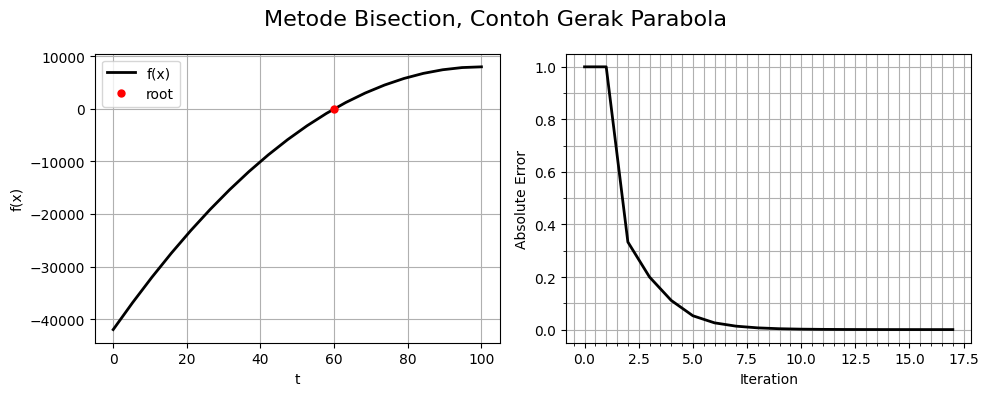

In [11]:
# Metode Biseksi (Bagi Dua), contoh kasus gerak parabola
# input batas akar
xi = 0 # batas awal
xf = 100 # batas akhir

# nilai toleransi error
tol = 1e-5
error = 1

# Jumlah iterasi
iter = 0

# definisikan fungsi kuadrat
f = lambda t : (-0.5*10)*(t**2) + 1000*t - 42000

if (f(xi) * f(xf)) < 0:
  print()
  print("Nilai akar berada dalam rentang")
  print()

  iteration, errors = [], []
  while error > tol:
    iteration.append(iter)
    errors.append(error)
    # hitung estimasi nilai akar awal
    xr = (xi + xf) / 2

    if f(xr) == 0:
      x_old = xr
      error = 0
      print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
      iter += 1
      break
    elif f(xi) * f(xr) < 0:
      x_old, xf = xf, xr
    elif f(xi) * f(xr) > 0:
      x_old, xi = xi, xr

    print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
    error = cal_absolute_error(xr,x_old)
    iter += 1

  print()
  print(f"Jumlah perulangan (iterasi): {iter}")
  print(f"Nilai akar, xr: {xr:.4f}")
  print(f"f(xr) = {f(xr):.3f}, error = {error:.5f}")
else:
  print("Masukan batas nilai yang baru")

# Plot grafik
plot_graphic(0,100,f, xr, iteration, errors, title='Metode Bisection, Contoh Gerak Parabola', xlabel='t')

#### Metode Regula Falsi


Nilai akar berada dalam rentang

Error: 1.00000, xr: 84.00000, f(xr): 6720.00000
Error: 0.19048, xr: 72.41379, f(xr): 4195.00595
Error: 0.16000, xr: 65.83784, f(xr): 2164.73338
Error: 0.09988, xr: 62.61080, f(xr): 1010.23777
Error: 0.05154, xr: 61.14018, f(xr): 449.57038
Error: 0.02405, xr: 60.49266, f(xr): 195.85008
Error: 0.01070, xr: 60.21189, f(xr): 84.52962
Error: 0.00466, xr: 60.09095, f(xr): 36.33689
Error: 0.00201, xr: 60.03900, f(xr): 15.59320
Error: 0.00087, xr: 60.01672, f(xr): 6.68653
Error: 0.00037, xr: 60.00717, f(xr): 2.86634
Error: 0.00016, xr: 60.00307, f(xr): 1.22856
Error: 0.00007, xr: 60.00132, f(xr): 0.52655
Error: 0.00003, xr: 60.00056, f(xr): 0.22567
Error: 0.00001, xr: 60.00024, f(xr): 0.09672

Jumlah perulangan (iterasi): 15
Nilai akar, xr: 60.0002
f(xr) = 0.097, error = 0.00001


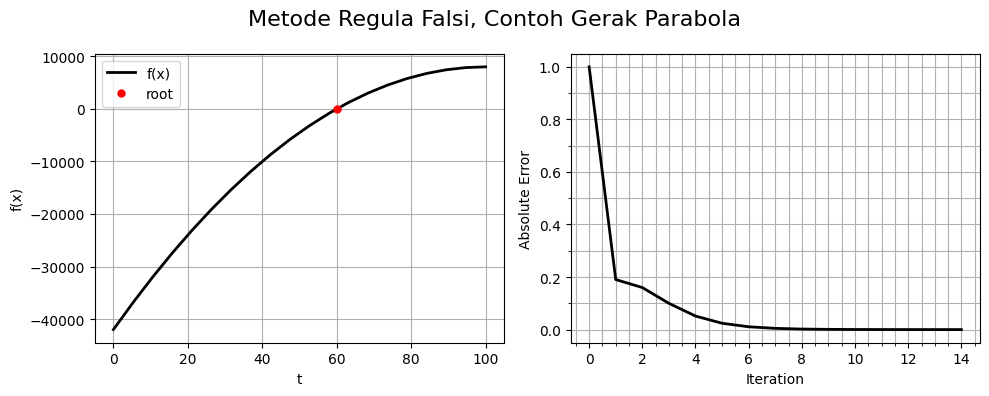

In [12]:
# Metode Regula Falsi, contoh kasus gerak parabola
# input batas akar
xi = 0 # batas awal
xf = 100 # batas akhir

# nilai toleransi error
tol = 1e-5
error = 1

# jumlah iterasi awal
iter = 0

# definisikan fungsi kuadrat
f = lambda t : (-0.5*10)*(t**2) + 1000*t - 42000

iteration, errors = [], []
if (f(xi) * f(xf)) < 0:
  print()
  print("Nilai akar berada dalam rentang")
  print()

  while error > tol:
    iteration.append(iter)
    errors.append(error)
    # hitung estimasi nilai akar awal
    xr = xi - ((f(xi)*(xf - xi))/(f(xf) - f(xi)))

    if f(xr) == 0:
      x_old = xr
      error = 0
      print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
      iter += 1
      break
    elif f(xi) * f(xr) < 0:
      x_old, xf = xf, xr
    elif f(xi) * f(xr) > 0:
      x_old, xi = xi, xr

    print(f"Error: {error:.5f}, xr: {xr:.5f}, f(xr): {f(xr):.5f}")
    error = cal_absolute_error(xr,x_old)

    iter += 1
  print()
  print(f"Jumlah perulangan (iterasi): {iter}")
  print(f"Nilai akar, xr: {xr:.4f}")
  print(f"f(xr) = {f(xr):.3f}, error = {error:.5f}")
else:
  print("Masukan batas nilai yang baru")

# Plot grafik
plot_graphic(0,100,f, xr, iteration, errors, title='Metode Regula Falsi, Contoh Gerak Parabola', xlabel='t')

Kedua metode mendapatkan hasil waktu tempuh roket pada ketinggian 42.100 m adalah 60.0002 s, dimana metode regula falsi relatif konvergen lebih cepat dibandingkan dengan metode biseksi. Metode regula falsi hanya melakukan 15 kali iterasi untuk mendapatkan nilai akar (waktu tempuh) dibandingkan dengan metode biseksi yang melakukan perulangan sebanyak 18 kali.